In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [30]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [31]:
CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

fashion_train = datasets.FashionMNIST(download=True, train=True, root='/data')
fashion_test = datasets.FashionMNIST(download=True, train=False, root='/data')

In [32]:
# train test split

X_train_full = fashion_train.data.numpy() # 60,000 , 28, 28
y_train_full = fashion_train.targets.numpy() # 60,000

x_test = fashion_test.data.numpy() # 10,000 , 28, 28
y_test = fashion_test.targets.numpy() # 10,000

X_train_full.shape, y_train_full.shape, x_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [33]:
# pixel - 0 - 255 -> 0-1 normalization

x_valid, X_train = X_train_full[:5000]/255. , X_train_full[5000:] / 255.
y_valid , y_train = y_train_full[:5000] , y_train_full[5000:]

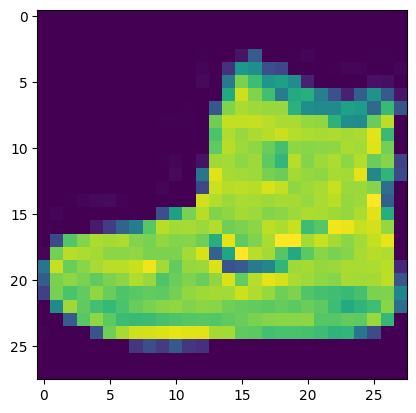

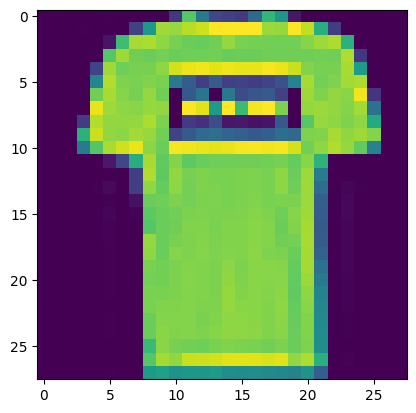

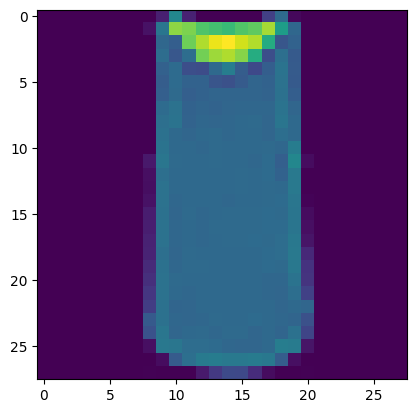

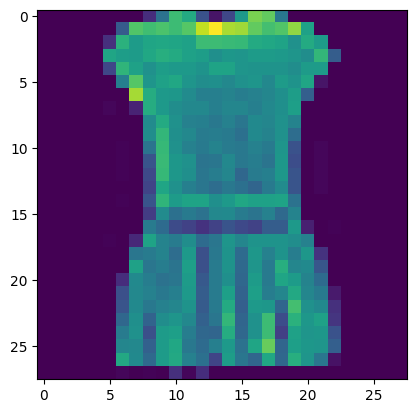

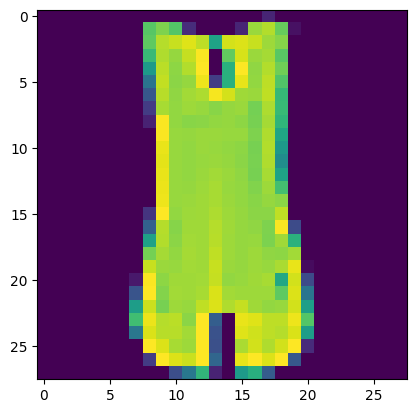

In [34]:
for i in range(0,5):
  plt.imshow(X_train_full[i])
  plt.show()

In [35]:
# ANN

class ANN(nn.Module):
  def __init__(self):
    super().__init__()
    self.inputlayer = nn.Flatten()
    self.hidden1 = nn.Linear(784,200)
    self.hidden2 = nn.Linear(200,100)
    self.output = nn.Linear(100,10)

  def forward(self, x):
    x = self.inputlayer(x)
    x = torch.relu(self.hidden1(x))
    x = torch.relu(self.hidden2(x))
    x = self.output(x)
    return x


In [42]:
model = ANN().to(device)

In [43]:
print(model)

ANN(
  (inputlayer): Flatten(start_dim=1, end_dim=-1)
  (hidden1): Linear(in_features=784, out_features=200, bias=True)
  (hidden2): Linear(in_features=200, out_features=100, bias=True)
  (output): Linear(in_features=100, out_features=10, bias=True)
)


In [44]:
# !pip install torchinfo
from torchinfo import summary
summary(model)

Layer (type:depth-idx)                   Param #
ANN                                      --
├─Flatten: 1-1                           --
├─Linear: 1-2                            157,000
├─Linear: 1-3                            20,100
├─Linear: 1-4                            1,010
Total params: 178,110
Trainable params: 178,110
Non-trainable params: 0

In [45]:
LOSS_FUNCTION = nn.CrossEntropyLoss()
OPTIMIZER = optim.Adam(model.parameters())
EPOCHS = 30

# Prepare data
train_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train)),
    batch_size=32, shuffle=True
)
X_valid_t = torch.FloatTensor(x_valid).to(device)
y_valid_t = torch.LongTensor(y_valid).to(device)

history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

def accuracy(outputs, labels):
    return (outputs.argmax(1) == labels).float().mean().item()

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    total_loss, total_acc = 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        OPTIMIZER.zero_grad()
        outputs = model(X_batch)
        loss = LOSS_FUNCTION(outputs, y_batch)
        loss.backward()
        OPTIMIZER.step()

        total_loss += loss.item()
        total_acc += accuracy(outputs, y_batch)

    train_loss = total_loss / len(train_loader)
    train_acc = total_acc / len(train_loader)

    # --- Validate ---
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_valid_t)
        val_loss = LOSS_FUNCTION(val_outputs, y_valid_t).item()
        val_acc = accuracy(val_outputs, y_valid_t)

    # --- Log ---
    history['loss'].append(train_loss)
    history['accuracy'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)

    print(f"Epoch {epoch+1:2d}/{EPOCHS} - loss: {train_loss:.4f} - accuracy: {train_acc:.4f} "
          f"- val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")

Epoch  1/30 - loss: 0.5215 - accuracy: 0.8131 - val_loss: 0.4199 - val_accuracy: 0.8466
Epoch  2/30 - loss: 0.3750 - accuracy: 0.8629 - val_loss: 0.3762 - val_accuracy: 0.8660
Epoch  3/30 - loss: 0.3347 - accuracy: 0.8768 - val_loss: 0.3149 - val_accuracy: 0.8878
Epoch  4/30 - loss: 0.3107 - accuracy: 0.8850 - val_loss: 0.3159 - val_accuracy: 0.8864
Epoch  5/30 - loss: 0.2931 - accuracy: 0.8921 - val_loss: 0.3137 - val_accuracy: 0.8844
Epoch  6/30 - loss: 0.2754 - accuracy: 0.8982 - val_loss: 0.3246 - val_accuracy: 0.8806
Epoch  7/30 - loss: 0.2642 - accuracy: 0.9019 - val_loss: 0.3136 - val_accuracy: 0.8856
Epoch  8/30 - loss: 0.2499 - accuracy: 0.9058 - val_loss: 0.3167 - val_accuracy: 0.8926
Epoch  9/30 - loss: 0.2399 - accuracy: 0.9087 - val_loss: 0.2995 - val_accuracy: 0.8944
Epoch 10/30 - loss: 0.2319 - accuracy: 0.9130 - val_loss: 0.2982 - val_accuracy: 0.8954
Epoch 11/30 - loss: 0.2216 - accuracy: 0.9160 - val_loss: 0.2956 - val_accuracy: 0.8992
Epoch 12/30 - loss: 0.2151 - acc

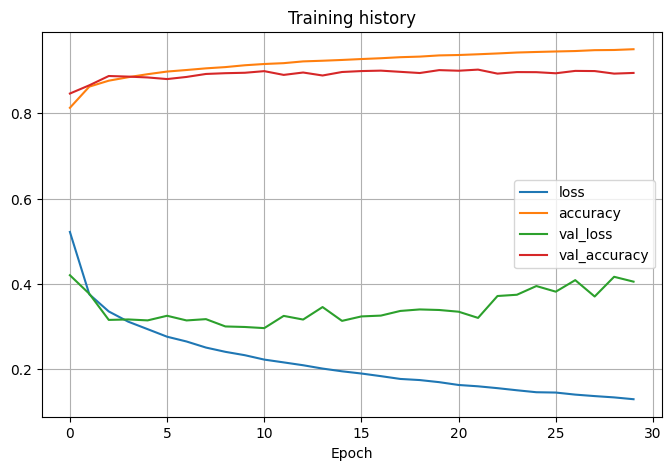

In [46]:
pd.DataFrame(history).plot(figsize=[8, 5])
plt.grid(True)
plt.xlabel('Epoch')
plt.title('Training history')
plt.show()

In [49]:
# Re-normalize just to be safe
X_test = fashion_test.data.numpy() / 255.
y_test = fashion_test.targets.numpy()

X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.LongTensor(y_test).to(device)

model.eval()
with torch.no_grad():
    test_outputs  = model(X_test_t)
    test_loss     = LOSS_FUNCTION(test_outputs, y_test_t).item()
    _, predicted  = torch.max(test_outputs, 1)
    test_accuracy = (predicted == y_test_t).float().mean().item()

print(f"Test loss: {test_loss:.4f}, Test accuracy: {test_accuracy:.4f}")

Test loss: 0.4646, Test accuracy: 0.8908


In [50]:
torch.save(model.state_dict(), 'fashion_ann_pytorch.pth')

loaded_model = ANN().to(device)
loaded_model.load_state_dict(torch.load('fashion_ann_pytorch.pth', weights_only=True))
loaded_model.eval()

ANN(
  (inputlayer): Flatten(start_dim=1, end_dim=-1)
  (hidden1): Linear(in_features=784, out_features=200, bias=True)
  (hidden2): Linear(in_features=200, out_features=100, bias=True)
  (output): Linear(in_features=100, out_features=10, bias=True)
)

In [51]:
new_x = X_test[:3]
new_y = y_test[:3]

new_x_t = torch.FloatTensor(new_x).to(device)
loaded_model.eval()
with torch.no_grad():
    y_proba = torch.softmax(loaded_model(new_x_t), dim=1).cpu().numpy()

y_pred = np.argmax(y_proba, axis=1)

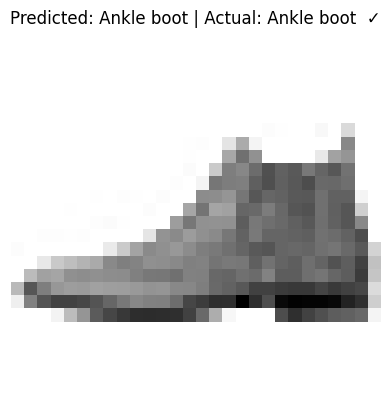

--------------------------------------------------------------------------------


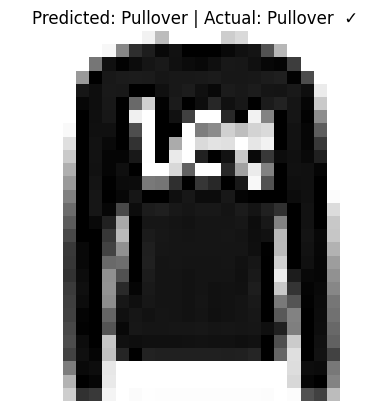

--------------------------------------------------------------------------------


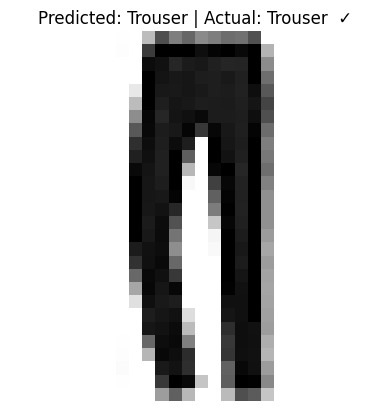

--------------------------------------------------------------------------------


In [52]:
for data, pred, actual in zip(new_x, y_pred, new_y):
    plt.imshow(data, cmap='binary')
    correct = "✓" if pred == actual else "✗"
    plt.title(f"Predicted: {CLASS_NAMES[pred]} | Actual: {CLASS_NAMES[actual]}  {correct}")
    plt.axis('off')
    plt.show()
    print('-' * 80)